<a href="https://colab.research.google.com/github/Yashaswiniramashesh/Small-GPT-from-scratch/blob/main/training_loop.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import jax
import jax.numpy as jnp
import flax.nnx as nnx
import grain.python as pygrain
import tiktoken
import optax

In [5]:
import importlib
from mini_gpt_utils import MiniGPT,generate_text,load_and_preprocess_data, generate_story

In [6]:
maxlen =128
tokenizer = tiktoken.get_encoding("gpt2")

In [7]:
text_dl, batches_per_epoch = load_and_preprocess_data(
    file_path='TinyStories-train.txt',
    batch_size=32,
    maxlen=128,
    max_stories=40000,
    shuffle=False,
    seed=42
)

Loading data from TinyStories-train.txt (max40,000 stories)
Loaded 40,000 stories
Estimated batches per epoch: 1,250
Created DataLoader with batch_size=32, maxlen=128


In [8]:
model = MiniGPT()

In [9]:
def loss_fn(model, batch):
  inputs, targets = batch
  logits = model(inputs)
  loss = optax.softmax_cross_entropy_with_integer_labels(
      logits, targets
  ).mean()
  return loss, logits

In [10]:
num_epochs=10
total_steps = batches_per_epoch * num_epochs
warmup_steps = max(1, total_steps//10)
print(f"Total training steps: {total_steps:,}")

Total training steps: 12,500


In [11]:
lr_schedule = optax.warmup_cosine_decay_schedule(
    init_value=0.0,
    peak_value=3e-4,
    warmup_steps=warmup_steps,
    decay_steps=total_steps,
    end_value=1e-5
)

Optimizer

In [12]:
optimizer = nnx.ModelAndOptimizer(
    model,
    optax.adamw(learning_rate=lr_schedule, weight_decay=0.01)
)

In [13]:
metrics = nnx.MultiMetric(
    loss=nnx.metrics.Average('loss'),
)

In [14]:
@nnx.jit
def train_step(model, optimizer, metrics, batch):
  grad_fn = nnx.value_and_grad(loss_fn, has_aux=True)
  (loss, logits), grads = grad_fn(model, batch)

  metrics.update(loss=loss, logits=logits, labels=batch[1])
  optimizer.update(grads)

Training loop

In [15]:
metrics_history = {'train_loss': []}

prep_target_batch =jax.vmap(lambda tokens: jnp.concatenate((tokens[1:], jnp.array([0]))))

for epoch in range(num_epochs):
    step = 0
    for batch in text_dl:
        input_batch = jnp.array(jnp.array(batch).T).astype(jnp.int32)
        target_batch = prep_target_batch(
            jnp.array(jnp.array(batch).T)).astype(jnp.int32)
        print(".", end="")
        train_step(model, optimizer, metrics, (input_batch, target_batch))

        if (step + 1) % 20 == 0:
            for metric, value in metrics.compute().items():
                metrics_history[f'train_{metric}'].append(value)
            metrics.reset()

            current_lr = lr_schedule(step)
            print(f"\nEpoch: {epoch + 1}, Step {step + 1}, Loss: {metrics_history['train_loss'][-1]:.4f}, "
                  f"LR: {current_lr:.2e}")
        step += 1

....................
Epoch: 1, Step 20, Loss: 10.8789, LR: 4.56e-06
....................
Epoch: 1, Step 40, Loss: 10.8288, LR: 9.36e-06
....................
Epoch: 1, Step 60, Loss: 10.7314, LR: 1.42e-05
....................
Epoch: 1, Step 80, Loss: 10.5458, LR: 1.90e-05
....................
Epoch: 1, Step 100, Loss: 10.1411, LR: 2.38e-05
....................
Epoch: 1, Step 120, Loss: 9.5860, LR: 2.86e-05
....................
Epoch: 1, Step 140, Loss: 8.9339, LR: 3.34e-05
....................
Epoch: 1, Step 160, Loss: 8.3356, LR: 3.82e-05
....................
Epoch: 1, Step 180, Loss: 7.8066, LR: 4.30e-05
....................
Epoch: 1, Step 200, Loss: 7.3848, LR: 4.78e-05
....................
Epoch: 1, Step 220, Loss: 6.8499, LR: 5.26e-05
....................
Epoch: 1, Step 240, Loss: 6.6243, LR: 5.74e-05
....................
Epoch: 1, Step 260, Loss: 6.3335, LR: 6.22e-05
....................
Epoch: 1, Step 280, Loss: 6.2506, LR: 6.70e-05
....................
Epoch: 1, Step 300, Loss: 

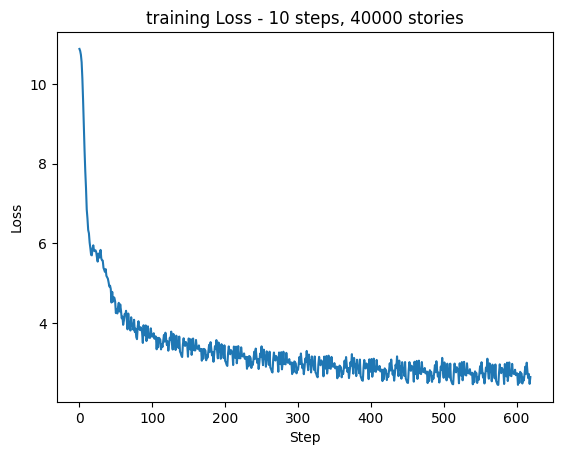

In [16]:
import matplotlib.pyplot as plt

plt.plot(metrics_history['train_loss'])
plt.title('training Loss - 10 steps, 40000 stories')
plt.xlabel('Step')
plt.ylabel('Loss')
plt.show()

In [17]:
def create_story(story_prompt, temperature, max_new_tokens):
  return generate_story(model, story_prompt, temperature,max_new_tokens)

In [18]:
create_story("One day, a little girl named Lily found a needle in her room", 0.1, 50)

'One day, a little girl named Lily found a needle in her room. She was very happy and wanted to play with her friends.\nOne day, Lily\'s mom came to the park. She saw a big, red ball and said, "Look, Lily, Lily! I can\'t be careful!"\nL'

In [19]:
from pathlib import Path
import orbax

checkpoint_path = Path.cwd() / "full_model_checkpoint.orbax"

checkpointer = orbax.checkpoint.PyTreeCheckpointer()

checkpointer.save(checkpoint_path, nnx.state(model), force=True)
print(f"Model saved as {checkpoint_path}")

Model saved as /content/full_model_checkpoint.orbax


In [20]:
import os
import zipfile

checkpoint_dir = '/content/full_model_checkpoint.orbax'
zip_file_name = '/content/full_model_checkpoint.zip'

with zipfile.ZipFile(zip_file_name, 'w', zipfile.ZIP_DEFLATED) as zipf:
    for root, dirs, files in os.walk(checkpoint_dir):
        for file in files:
            file_path = os.path.join(root, file)
            arcname = os.path.relpath(file_path, checkpoint_dir)
            zipf.write(file_path, os.path.join(os.path.basename(checkpoint_dir), arcname))

print(f"Directory '{checkpoint_dir}' successfully zipped to '{zip_file_name}'")

Directory '/content/full_model_checkpoint.orbax' successfully zipped to '/content/full_model_checkpoint.zip'
